In [ ]:
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import torch

from matplotlib.patches import Rectangle, Circle
from matplotlib.axes import Axes
from neuralop.models import FNO
from pathlib import Path

file_ext = "eval_single"

def fno_input_converter(
    sources: np.ndarray,
    shape: str = "sphere",
    dim: int = 2,
    lim: int = 3,
    res: int = 32,
):
    """Convert source parameters to FNO input format."""
    m, r0, size = np.split(sources, 3, axis=-1)
    n_sources, _ = r0.shape
    
    grid_x = np.linspace(-lim, lim, res)
    grid_y = np.linspace(-lim, lim, res)
    if dim > 2:
        grid_z = np.linspace(-lim, lim, res)
        grids = np.meshgrid(grid_x, grid_y, grid_z, indexing="xy")
    else:
        grids = np.meshgrid(grid_x, grid_y, indexing="xy")

    grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
    input_data = np.zeros((res**dim, dim))

    for n in range(n_sources):
        if shape == "sphere":
            idx_in = np.where(
                np.linalg.norm(grid - r0[n], axis=1) <= size[n, 0]
            )[0]
        elif shape == "prism":
            idx_in = np.where(
                (np.abs(grid[:, 0] - r0[n, 0]) <= size[n, 0])
                & (np.abs(grid[:, 1] - r0[n, 1]) <= size[n, 1])
            )[0]
        else:
            raise ValueError("Unknown shape")

        input_data[idx_in] += m[n, :dim]

    return input_data

def read_db(filename: str):
    datapath = Path.cwd() / ".." / "data"
    db = h5py.File(datapath / filename, "r")
    data = {
        "sources": np.concatenate(
            [
                db["m"][:],
                db["r0"][:],
                db["size"][:],
            ],
            axis=-1,
        ),
        "r": np.array(db["r"][:]),
        "msp": np.array(db["msp"][:]),
        "field": np.array(db["field"][:]),
        "grid": np.array(db["grid"][:]),
        "msp_grid": np.array(db["msp_grid"][:]),
        "field_grid": np.array(db["field_grid"][:]),
        "field_eval": db.attrs["field_eval"],
        "target_source": db.attrs["target_source"],
        "shape": db.attrs["shape"],
        "lim": db.attrs["lim"],
    }
    db.close()

    _, _, size = np.split(data["sources"], 3, axis=-1)
    data["max_size"] = np.max(size[..., :2])
    data["min_size"] = np.min(size[..., :2])

    return data

def _plot_shape(ax, r0, m, size, shape, loc, edge):
    # Dot at source location
    if loc:
        ax.scatter(r0[0, :, 0], r0[0, :, 1], color="red")
        ax.quiver(
            r0[0, :, 0],
            r0[0, :, 1],
            m[0, :, 0] / 10,
            m[0, :, 1] / 10,
            angles="xy",
            scale_units="xy",
            scale=5,
            color="red",
        )
    # Edge of magnetized bodies
    if edge:
        for i in range(r0.shape[1]):
            if shape == "sphere":
                edge = Circle(
                    (r0[0, i, 0], r0[0, i, 1]),
                    size[0, i, 0],
                    fill=False,
                    edgecolor="red",
                )
            elif shape == "prism":
                edge = Rectangle(
                    (
                        r0[0, i, 0] - size[0, i, 0],
                        r0[0, i, 1] - size[0, i, 1],
                    ),
                    size[0, i, 0] * 2,
                    size[0, i, 1] * 2,
                    fill=False,
                    edgecolor="red",
                )
            else:
                raise ValueError(f"Unknown shape: {shape}")

            ax.add_patch(edge)

def _plot(
    axes: Axes,
    data: dict,
    idx: int,
    prefix: str,
    loc: bool,
    edge: bool,
    number: bool,
    vmax: float | None = None,
):
    mr = data["sources"][idx : idx + 1]
    m, r0, size = np.split(mr, 3, axis=-1)

    res = int(np.sqrt(len(data["grid"])))
    x_grid = np.array(data["grid"][:, 0].reshape((res, res)))
    y_grid = np.array(data["grid"][:, 1].reshape((res, res)))

    msp = data["msp_grid"][idx]
    field = data["field_grid"][idx][..., :2]

    xlims = (x_grid.min(), x_grid.max())
    ylims = (y_grid.min(), y_grid.max())

    if vmax is not None:
        norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    else:
        norm = mcolors.TwoSlopeNorm(vmin=msp.min(), vcenter=0, vmax=msp.max())

    # Subplot 1: Magnetic Scalar Potential
    axes[0].contourf(
        x_grid,
        y_grid,
        msp.reshape((res, res)),
        levels=250,
        cmap="viridis",
        norm=norm,
    )
    _plot_shape(axes[0], r0, m, size, data["shape"], loc, edge)
    if number:
        for i in range(r0.shape[1]):
            axes[0].text(
                r0[0, i, 0] + 0.05,
                r0[0, i, 1] + 0.05,
                str(i),
                color="black",
                fontsize=12,
                ha="center",
                va="center",
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.7),
            )

    axes[0].set_title(prefix + " " + "Magnetic Scalar Potential")
    units_str = ", in units of source radius"
    axes[0].set_xlabel("$x$" + units_str)
    axes[0].set_ylabel("$y$" + units_str)
    axes[0].set_xlim(xlims)
    axes[0].set_ylim(ylims)

    # Subplot 2: Magnetic Field
    axes[1].streamplot(
        x_grid,
        y_grid,
        field[..., 0].reshape((res, res)),
        field[..., 1].reshape((res, res)),
        density=1.5,
        linewidth=0.5,
        arrowsize=1.5,
        arrowstyle="->",
    )
    _plot_shape(axes[1], r0, m, size, data["shape"], loc, edge)

    axes[1].set_title(prefix + " " + "Magnetic Field")
    axes[1].set_xlabel("x" + units_str)
    axes[1].set_ylabel("y" + units_str)
    axes[1].set_xlim(xlims)
    axes[1].set_ylim(ylims)

def plots(
    data: dict,
    loc: bool = True,
    edge: bool = False,
    number: bool = False,
    idx: int = 0,
    prefix: str = "",
    output: str = "show",
    model=None,
    vmax: float | None = None,
):
    """
    Plots the sources and field/potential of a single sample.

    Parameters:
        sources (dict): The source data containing positions, magnetizations, and sizes.
        loc (bool): Whether to plot the source positions.
        edge (bool): Whether to plot the shapes of the sources.
        numbers (bool): Whether to plot the source numbers.
        idx (int): The index of the sample to plot.
        prefix (str): A prefix for the plot titles.
        output (str): The output mode for the plot (e.g., "show", "save").
        model (HyperLayer): The trained model to use for predictions.
    """
    if model is None:
        _, axes = plt.subplots(1, 2, figsize=(8, 4))
        _plot(axes, data, idx, prefix, loc, edge, number, vmax)
    else:
        _, axes = plt.subplots(2, 2, figsize=(8, 8))
        _plot(axes[0], data, idx, prefix, loc, edge, number, vmax)
        _plot(axes[1], data, idx, prefix, loc, edge, number, vmax, model=model)

    plt.tight_layout()

    if output == "show":
        plt.show()
    elif output == "save":
        plt.savefig(
            Path.cwd() / ".." / "figs" / f"{prefix}_plot_{idx}.png",
            dpi=300,
        )
    else:
        raise ValueError(f"Unknown output mode: {output}")

In [ ]:
# db_name = "val_eval_large_m_92_1000_1"
db_name = "eval_large_m_qt_42_10_50"
# db_name = "eval_large_m_42_10_10"
figname = "fno_multi"

res = 32
idx = 1
plot = False

if res == 128 or res == 64:
    res_out = res // 4
    fno_res = 128
else:
    res_out = res
    fno_res = 32
lim = 1.2

datapath = Path.cwd() / ".." / "data"
figpath = Path.cwd() / ".." / "figs"

if file_ext == "eval_single":
    if db_name == "val_eval_large_m_92_1000_1":
        batch_size = 990
    else:
        batch_size = 10
    db = h5py.File(datapath / f"{db_name}_fno_{res}.h5", "r")
    input = (
        np.array(db["input"][:batch_size])
        .reshape(batch_size, res, res, -1)
        .transpose(0, 3, 1, 2)
    )
    t_msp = np.array(db["output"][:batch_size]).reshape(
        batch_size, res_out, res_out
    )
else:
    if file_ext == "single":
        sources = np.load(datapath / f"sources_{file_ext}_9_2.npy")
        t_msp = np.load(datapath / f"gt_msp_grid_{file_ext}_9_2.npy")
    elif file_ext == "qt":
        sources = np.load(datapath / f"sources_{file_ext}_0_1.npy")
        t_msp = np.load(datapath / f"gt_msp_grid_{file_ext}_0_1.npy")
    else:
        sources = np.load(datapath / "sources_1_1.npy")
        t_msp = np.load(datapath / "gt_msp_grid_1_1.npy")

    # Check fno function
    input = fno_input_converter(sources, shape="prism", res=res, lim=1.2)

print(input.shape)
grids = np.meshgrid(
            np.linspace(-lim, lim, res),
            np.linspace(-lim, lim, res),
            np.linspace(0, 0, 1),
        )
grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid = np.array(grid[:, 0].reshape((res, res)))
y_grid = np.array(grid[:, 1].reshape((res, res)))

# Plot example
if file_ext == "eval_single":
    db = h5py.File(datapath / f"{db_name}.h5", "r")
    sources = np.concatenate(
            [
                db["m"][idx:idx+1],
                db["r0"][idx:idx+1],
                db["size"][idx:idx+1],
            ],
            axis=-1,
        )
    db.close()
    print(sources)
    plots(read_db(datapath / f"{db_name}.h5"), loc=True, edge=True, idx=idx, output="save", prefix=figname)

    v_max = np.max(np.abs(np.sqrt(input[idx,0]**2 + input[idx,1]**2)))
    norm = mcolors.Normalize(vmin=-v_max, vmax=v_max)
    for i in range(2):
        contour = plt.scatter(x_grid, y_grid, c=input[idx, i].reshape((res, res)), cmap='magma', s=3, edgecolors='none', norm=norm)
        plt.colorbar(contour)
        if plot:
            plt.savefig(figpath / f"{figname}_input_{res}_plot_{idx}_{i}.png", dpi=300)
            # plt.savefig(figpath / f"{figname}_input_{res}_plot_{idx}_{i}.svg", format='svg')
        plt.show()
else:
    print(sources.shape)
    contour = plt.scatter(x_grid, y_grid, c=input[..., 0].reshape((res, res)), cmap='viridis', s=3, edgecolors='none')
    plt.colorbar(contour)


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/spol/Documents/repos/hypermagnetics/nbs/../data/eval_large_m_qt_42_10_50_fno_16.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
modelpath = Path.cwd() / ".." / "models" / "fno"
modelname = f"fno_large_m_{fno_res}_1M"
model = FNO.from_checkpoint(save_folder=modelpath, save_name=modelname)

if file_ext == "eval_single":
    input = torch.from_numpy(input.astype("float32"))
else:
    input = torch.from_numpy((
        np.array(input[None, :])
        .reshape(1, res, res, -1)
        .transpose(0, 3, 1, 2)).astype(np.float32)
    )
out = model(input).to("cpu").detach().numpy()
out = out.reshape(-1, res_out, res_out)
print(out.shape)

(10, 16, 16)


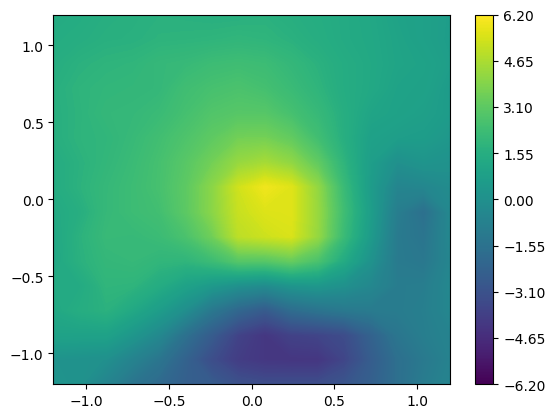

In [ ]:
grids = np.meshgrid(
            np.linspace(-lim, lim, res_out),
            np.linspace(-lim, lim, res_out),
            np.linspace(0, 0, 1),
        )
grid_out = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid_out = np.array(grid_out[:, 0].reshape((res_out, res_out)))
y_grid_out = np.array(grid_out[:, 1].reshape((res_out, res_out)))

if file_ext == "single":
    vmax = 2.5
elif file_ext == "qt":
    vmax = 4.5
elif file_ext == "eval_single":
    vmax = np.max(np.abs(t_msp[idx]))
else:
    vmax = 10
cbar_ticks = np.linspace(-vmax, vmax, 9)

norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
levels = np.linspace(-vmax, vmax, 250)  # evenly spaced, symmetric levels
contour = plt.contourf(x_grid_out, y_grid_out, out[idx], levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)
if plot:
    plt.savefig(figpath / f"{figname}_out_{res}_plot_{idx}.png", dpi=300)
    plt.savefig(figpath / f"{figname}_out_{res}_plot_{idx}.svg", format='svg')

(10, 16, 16)


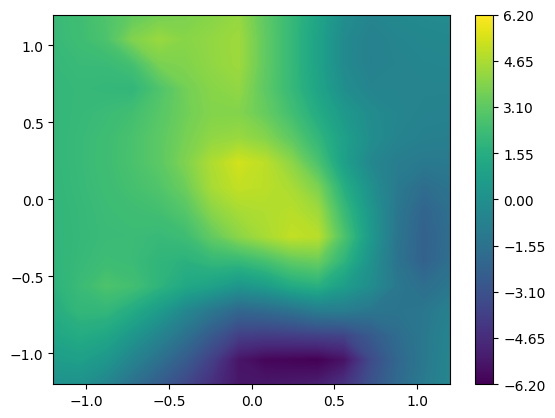

In [ ]:
print(t_msp.shape)
if file_ext == "eval_single":
    contour = plt.contourf(x_grid_out, y_grid_out, t_msp[idx], levels=levels, cmap='viridis', norm=norm)
else:
    contour = plt.contourf(x_grid_out, y_grid_out, np.clip(t_msp, -vmax, vmax), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)
if plot:
    plt.savefig(figpath / f"{figname}_gt_{res}_plot_{idx}.png", dpi=300)

Max: 0.2296878
Mean: 0.085518956
Median: 0.069736525


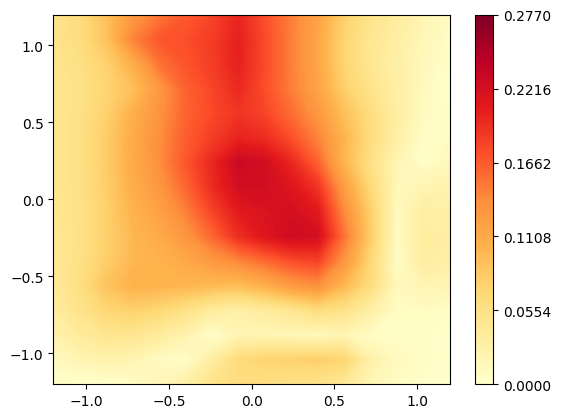

In [ ]:
# Relative Error FNO
abs_err_fno = np.abs(np.array(out)[idx,0]  - t_msp[idx]) / v_max
print("Max:", np.max(abs_err_fno))
print("Mean:", np.mean(abs_err_fno))
print("Median:", np.median(abs_err_fno))
if db_name == "val_eval_large_m_92_1000_1":
    vmax_rel = v_max * 0.015
else:
    vmax_rel = v_max * 0.0075
vmin_rel = 0

levels_rel = np.linspace(vmin_rel, vmax_rel, 250)
contour_rel = plt.contourf(x_grid_out, y_grid_out, abs_err_fno, cmap="YlOrRd", levels=levels_rel)
cbar = plt.colorbar(contour_rel)
cbar.set_ticks(np.linspace(vmin_rel, vmax_rel, 6))
if plot:
    plt.savefig(figpath / f"{figname}_abs_err_{res}_plot_{idx}.png", dpi=300)

Max: 23482.674
Mean: 162.94391
Std 1467.774
Median: 25.607803


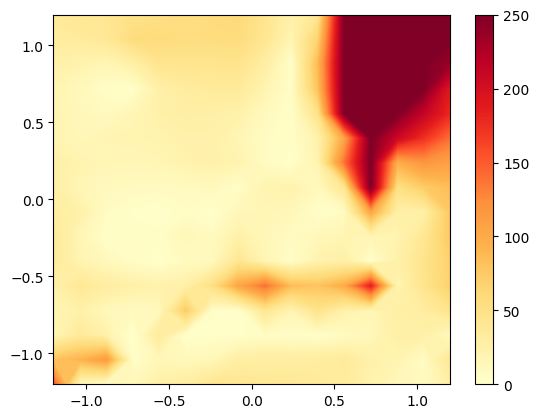

In [ ]:
# Relative Error FNO
err_fno = ((np.abs(np.array(out)[idx]  - t_msp[idx])) / np.abs(t_msp[idx])) * 100
print("Max:", np.max(err_fno))
print("Mean:", np.mean(err_fno))
print("Std", np.std(err_fno))
print("Median:", np.median(err_fno))
if db_name == "val_eval_large_m_92_1000_1":
    vmax_rel = 25
else:
    vmax_rel = 250
vmin_rel = 0

levels_rel = np.linspace(vmin_rel, vmax_rel, 250)
# norm = mcolors.LogNorm(vmin=vmin_rel, vmax=vmax_rel)
norm = mcolors.Normalize(vmin=vmin_rel, vmax=vmax_rel)
contour_rel = plt.contourf(x_grid_out, y_grid_out, np.clip(err_fno, vmin_rel, vmax_rel), cmap="YlOrRd", levels=levels_rel, norm=norm)
cbar = plt.colorbar(contour_rel)
cbar.set_ticks(np.linspace(vmin_rel, vmax_rel, 6))
plt.savefig(figpath / f"{figname}_rel_err_{res}_plot_{idx}.png", dpi=300)

In [ ]:
# Error full dataset
diff_pot = np.abs(t_msp - np.array(out))
rel_err_pot = np.abs(diff_pot / t_msp)
pot_strength = np.max(np.abs(t_msp))
print(pot_strength.shape)
m_pot = np.nanmedian(rel_err_pot.reshape((-1, res_out**2)), axis=-1) * 100
print("Mean", np.mean(m_pot))
print("Std", np.std(m_pot), "\n")

print("MAE Mean", np.mean(np.abs(diff_pot)) / pot_strength)
print("MAE Std", np.std(np.abs(diff_pot)) / pot_strength)

()
Mean 46.736317
Std 21.375172 

MAE Mean 0.08234608
MAE Std 0.06756993
